**AUTHOR: ANTOINE AMIEL**

In [1]:
# Import necessary libraries
import numpy as np
import sys
sys.path.append('../utils/')
sys.path.append('../src/')

from initial_param_SPA import initialize_parameters
from SPA import SPA
from plot_RESULT import plot_RESULT
from skimage.metrics import peak_signal_noise_ratio as psnr

# Load all parameters
params = initialize_parameters()

# Unpack parameters
D = params['D']
mu1 = params['mu1']
F_blur_kernel = params['F_blur_kernel']
F_Laplace = params['F_Laplace'] # smooth prior
rho = params['rho']
alpha = params['alpha']
img_noisy = params['img_noisy']
gamma = params['gamma']
N = params['N']
N_MC = params['N_MC']
N_bi = params['N_burn_in']
img_original = params['img_original']

Initial parameters loaded!


## Load workspace variables and launch SPA algorithm
Load workspace variables (defined in `../utils/initial_param_SPA.py`) and launch SPA algorithm.

In [2]:
# Run SPA algorithm
X_MC, _, _ = SPA(D, mu1, F_blur_kernel, rho, alpha, img_noisy, gamma, F_Laplace, N, N_MC)


BEGINNING OF THE SAMPLING


Sampling in progress: 100%|██████████| 999/999 [04:24<00:00,  3.78it/s]


END OF THE GIBBS SAMPLING
Execution time of the Gibbs sampling: 265.28 sec


## Display PSNR and SNR
Display PSNR and SNR associated to the MMSE estimator of x.

In [3]:
# Calculate MMSE estimator (mean of samples after burn-in)
X_MMSE = np.mean(X_MC[:, :, N_bi:N_MC], axis=2)

# Calculate PSNR and SNR
PSNR = psnr(img_original.astype(np.uint8), X_MMSE.astype(np.uint8))

# Calculate SNR manually (since skimage doesn't have SNR)
signal_power = np.sum(img_original**2)
noise_power = np.sum((img_original - X_MMSE)**2)
SNR = 10 * np.log10(signal_power / noise_power)

print(f'PSNR: {PSNR:.4f} dB')
print(f'SNR: {SNR:.4f} dB')

PSNR: 20.8156 dB
SNR: 19.7327 dB


## Plot the results
Display the original image, degraded image, and reconstructed results.

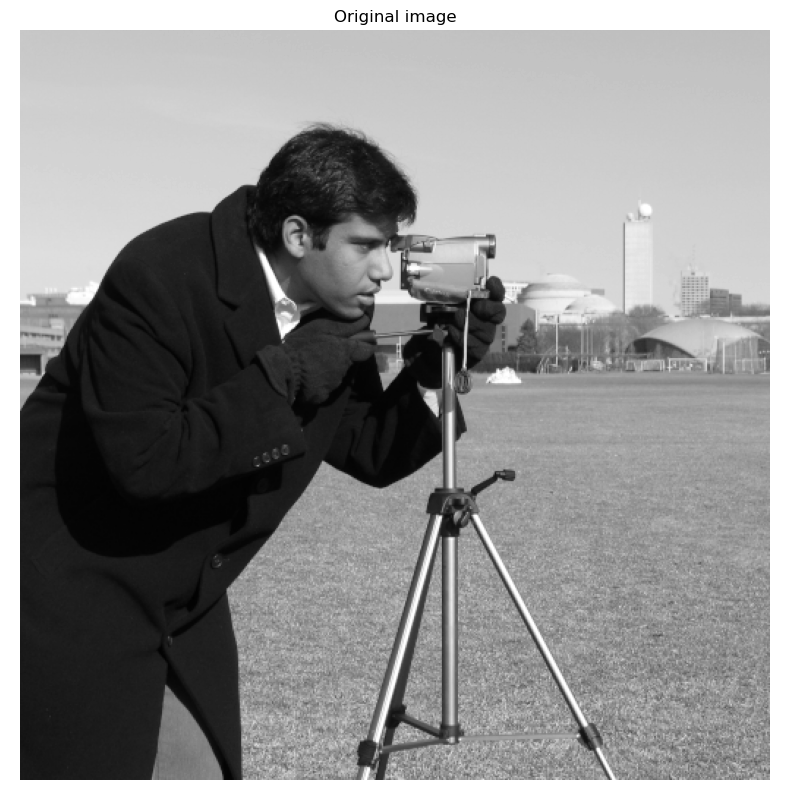

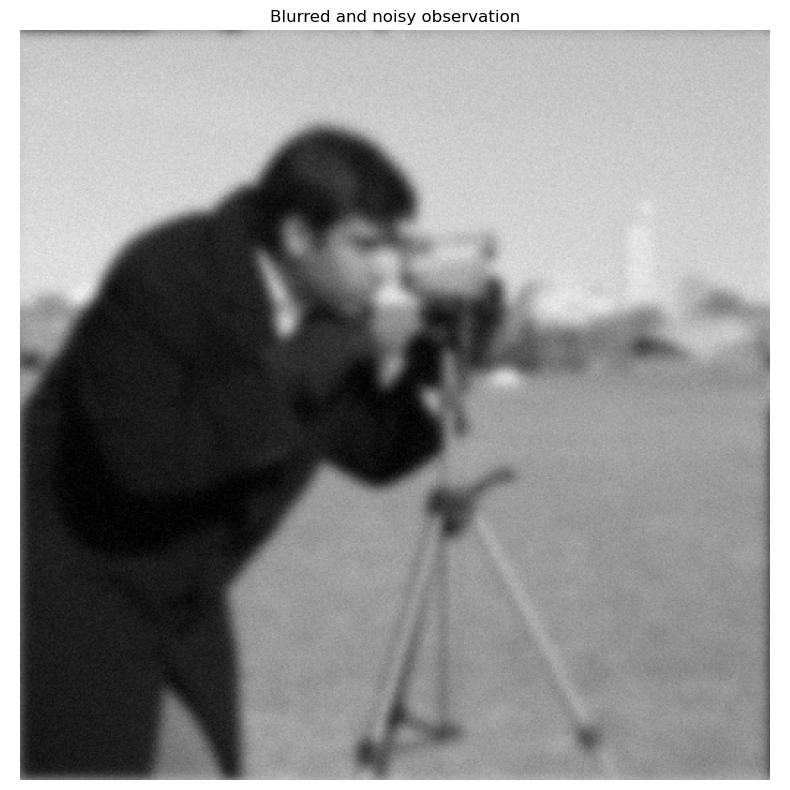

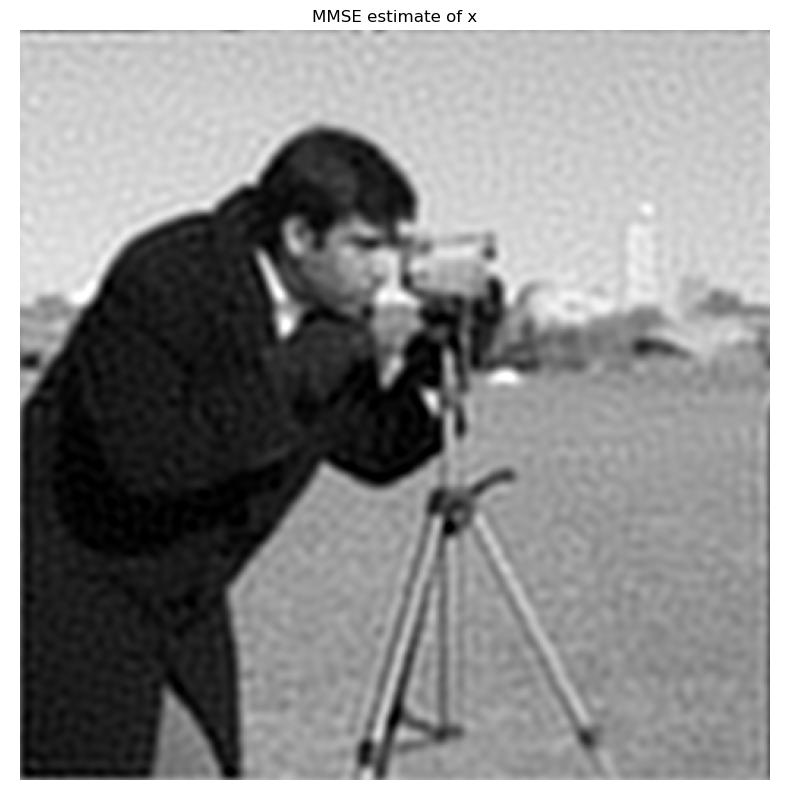

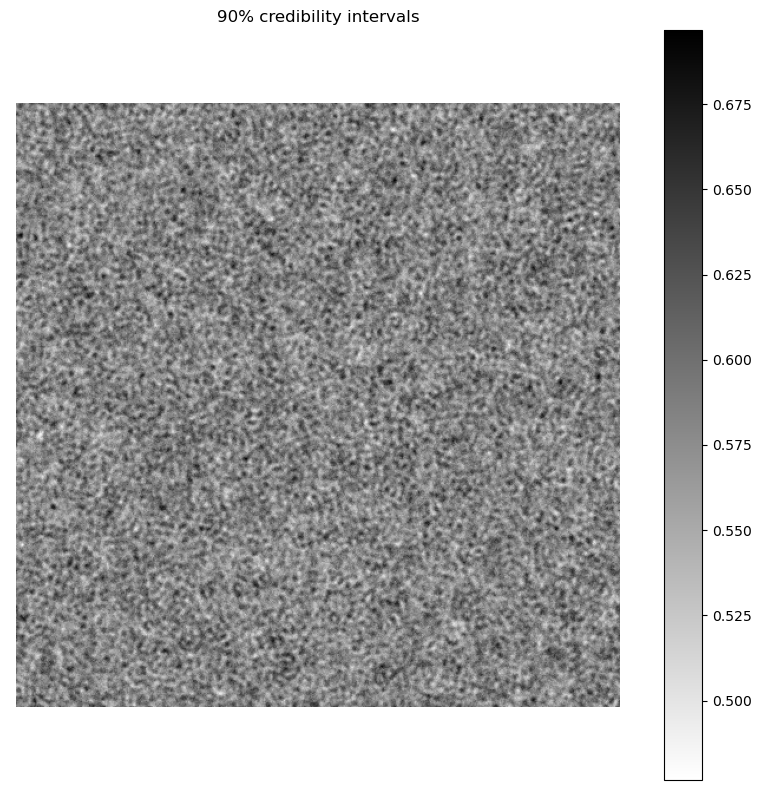

In [4]:
# Plot results
plot_RESULT(img_noisy, img_original, X_MC, N_bi, N)